In [12]:

import numpy as np
from pathlib import Path

from ephys_dimension_reduction_CD import coding_direction_from_psth
from create_psth import load_zarr
from general_utils import smart_read_csv, find_ephys_sessions
metadata_path = Path("/root/capsule/scratch/qc_passed_units_metadata_all_sessions.csv")
metadata = smart_read_csv(metadata_path)
metadata

,session_id,unit_index,brain_region,ccf_location,device_name,sorted_session_name
0,753124_2024-12-10_17-24-56,9,NaN,"{'best_electrode': 1, 'shank': 0, 'probe': 'Pr...",ProbeA,ecephys_753124_2024-12-10_17-24-56_sorted_2024...
1,753124_2024-12-10_17-24-56,14,NaN,"{'best_electrode': 7, 'shank': 0, 'probe': 'Pr...",ProbeA,ecephys_753124_2024-12-10_17-24-56_sorted_2024...
2,753124_2024-12-10_17-24-56,17,NaN,"{'best_electrode': 6, 'shank': 0, 'probe': 'Pr...",ProbeA,ecephys_753124_2024-12-10_17-24-56_sorted_2024...
3,753124_2024-12-10_17-24-56,20,NaN,"{'best_electrode': 6, 'shank': 0, 'probe': 'Pr...",ProbeA,ecephys_753124_2024-12-10_17-24-56_sorted_2024...
4,753124_2024-12-10_17-24-56,26,NaN,"{'best_electrode': 10, 'shank': 0, 'probe': 'P...",ProbeA,ecephys_753124_2024-12-10_17-24-56_sorted_2024...
...,...,...,...,...,...,...
24419,795396_2025-09-20_13-11-19,2880,NaN,"{'best_electrode': 22, 'shank': 3, 'probe': 'P...",ProbeD,ecephys_795396_2025-09-20_13-11-19_sorted_2025...
24420,795396_2025-09-20_13-11-19,2887,NaN,"{'best_electrode': 27, 'shank': 3, 'probe': 'P...",ProbeD,ecephys_795396_2025-09-20_13-11-19_sorted_2025...
24421,795396_2025-09-20_13-11-19,2888,NaN,"{'best_electrode': 27, 'shank': 3, 'probe': 'P...",ProbeD,ecephys_795396_2025-09-20_13-11-19_sorted_2025...
24422,795396_2025-09-20_13-11-19,2889,NaN,"{'best_electrode': 27, 'shank': 3, 'probe': 'P...",ProbeD,ecephys_795396_2025-09-20_13-11-19_sorted_2025...


In [ ]:
# Build CD zarrs across sessions × region groups × time windows
from pathlib import Path

from ephys_dimension_reduction_CD_pipeline import build_cd_dataset
from general_utils import smart_read_csv, find_ephys_sessions

# --- Config ---
binsize = "0.2"
align = "go_cue"
brain_regions_groups = [
    ["MD"],
    ["MOs2/3", "MOs5", "MOs6a"],
    ["SI", "MA"],
    [],  # empty => use all units for that session
]
time_windows = [[0.3, 2], [-1, 0]]
trial_types = ["right_choice_trials", "left_choice_trials"]

psth_root = Path("/root/capsule/scratch/psth_results")
behavior_root = Path("/root/capsule/scratch/behavior_summary")
cd_root = Path("/root/capsule/scratch/CD_results")
metadata_path = Path("/root/capsule/scratch/qc_passed_units_metadata_all_sessions.csv")

# --- Run ---
metadata = smart_read_csv(metadata_path)
sessions = find_ephys_sessions()[2]
print("Total sessions:", len(sessions))

failed = build_cd_dataset(
    sessions=sessions,
    psth_root=psth_root,
    behavior_root=behavior_root,
    cd_root=cd_root,
    metadata=metadata,
    binsize=binsize,
    align=align,
    brain_regions_groups=brain_regions_groups,
    time_windows=time_windows,
    trial_types=trial_types,
    projection_time_window=None,
    two_fold_cv=True,
    norm_mode="divide_sqrtN",
    min_units_num=30,
    overwrite=True,
)


Total sessions (index 2): 41

Session: ecephys_753124_2024-12-10_17-24-56_sorted_2024-12-13_09-48-25
  Skip region RG_MD (MD): 0 units < min 30
  Skip region RG_MOs2_3_MOs5_MOs6a (MOs2/3, MOs5, MOs6a): 0 units < min 30
  Skip region RG_SI_MA (SI, MA): 0 units < min 30
  Region RG_ALL (ALL): 528 units
    ✔ Finished time window [0.3, 2]: /root/capsule/scratch/CD_results/CD_ecephys_753124_2024-12-10_17-24-56_sorted_2024-12-13_09-48-25_RG_ALL_right_choice_trials_left_choice_trials_TW_0.3_2.zarr
    ✔ Finished time window [-1, 0]: /root/capsule/scratch/CD_results/CD_ecephys_753124_2024-12-10_17-24-56_sorted_2024-12-13_09-48-25_RG_ALL_right_choice_trials_left_choice_trials_TW_-1_0.zarr

Session: ecephys_753125_2024-10-09_10-50-19_sorted_2024-11-09_20-03-58
  Skip region RG_MD (MD): 0 units < min 30
  Skip region RG_MOs2_3_MOs5_MOs6a (MOs2/3, MOs5, MOs6a): 0 units < min 30
  Skip region RG_SI_MA (SI, MA): 0 units < min 30
  Region RG_ALL (ALL): 248 units
    ✔ Finished time window [0.3, 2]: 

[skip] does not match required suffix: CD_ecephys_753124_2024-12-10_17-24-56_sorted_2024-12-13_09-48-25_RG_ALL_right_choice_trials_left_choice_trials_TW_-1_0.zarr
[skip] does not match required suffix: CD_ecephys_753124_2024-12-10_17-24-56_sorted_2024-12-13_09-48-25_RG_ALL_right_choice_trials_left_choice_trials_TW_0.3_2.zarr
[skip] does not match required suffix: CD_ecephys_753125_2024-10-09_10-50-19_sorted_2024-11-09_20-03-58_RG_ALL_right_choice_trials_left_choice_trials_TW_-1_0.zarr
[skip] does not match required suffix: CD_ecephys_753125_2024-10-09_10-50-19_sorted_2024-11-09_20-03-58_RG_ALL_right_choice_trials_left_choice_trials_TW_0.3_2.zarr
[skip] does not match required suffix: CD_ecephys_753125_2024-10-10_14-41-23_sorted_2024-11-09_20-18-36_RG_ALL_right_choice_trials_left_choice_trials_TW_-1_0.zarr
[skip] does not match required suffix: CD_ecephys_753125_2024-10-10_14-41-23_sorted_2024-11-09_20-18-36_RG_ALL_right_choice_trials_left_choice_trials_TW_0.3_2.zarr
[skip] does not mat

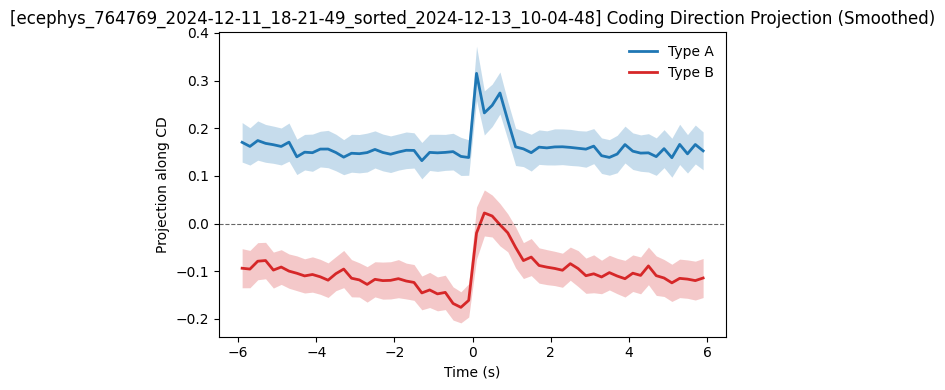

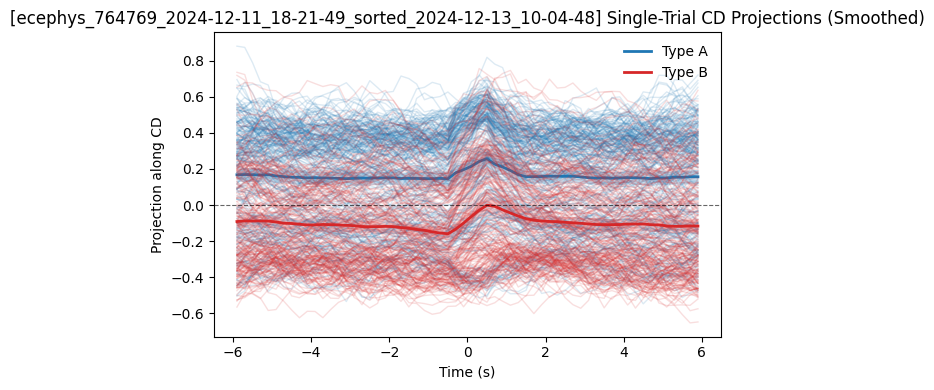

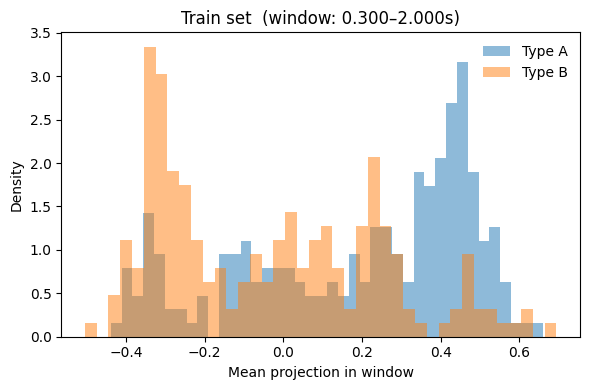

[skip] does not match required suffix: CD_ecephys_764769_2024-12-11_18-21-49_sorted_2024-12-13_10-04-48_RG_MD_right_choice_trials_left_choice_trials_TW_0.3_2.zarr
[skip] does not match required suffix: CD_ecephys_764769_2024-12-12_16-05-00_sorted_2024-12-13_10-34-23_RG_ALL_right_choice_trials_left_choice_trials_TW_-1_0.zarr
[skip] does not match required suffix: CD_ecephys_764769_2024-12-12_16-05-00_sorted_2024-12-13_10-34-23_RG_ALL_right_choice_trials_left_choice_trials_TW_0.3_2.zarr

=== Session: ecephys_764769_2024-12-12_16-05-00_sorted_2024-12-13_10-34-23 ===
File: CD_ecephys_764769_2024-12-12_16-05-00_sorted_2024-12-13_10-34-23_RG_MD_right_choice_trials_left_choice_trials_TW_-1_0.zarr
Train A  (LR / RL): 17 / 0
Train B  (LR / RL): 0 / 15
Test  A  (LR / RL): 17 / 0
Test  B  (LR / RL): 0 / 15


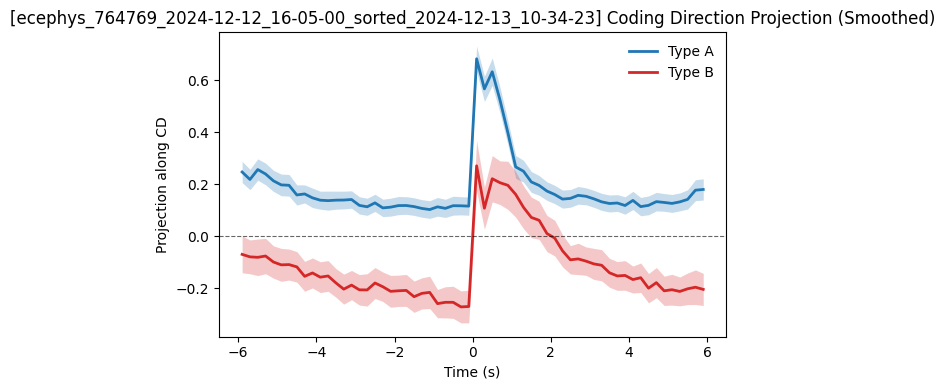

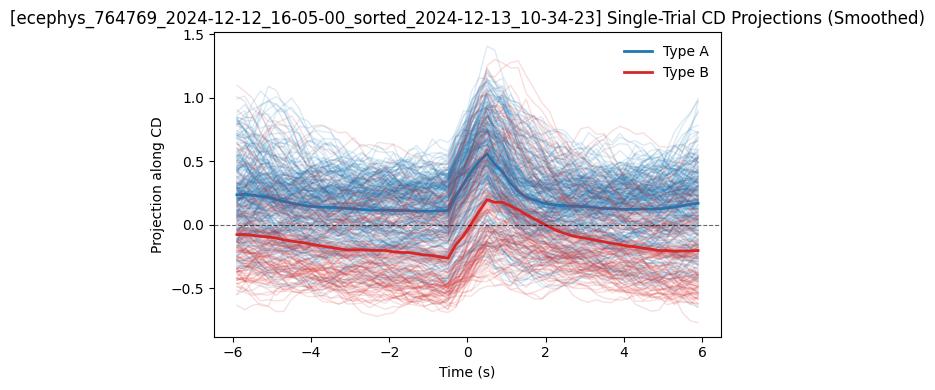

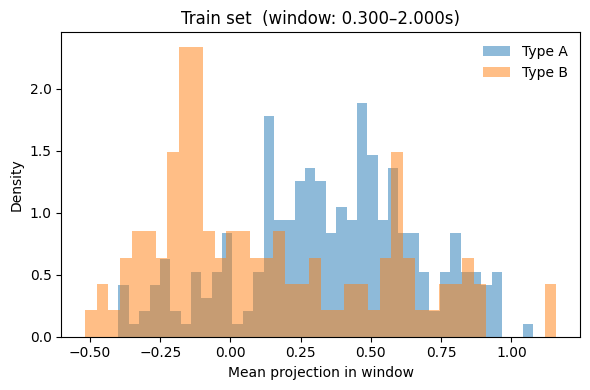

[skip] does not match required suffix: CD_ecephys_764769_2024-12-12_16-05-00_sorted_2024-12-13_10-34-23_RG_MD_right_choice_trials_left_choice_trials_TW_0.3_2.zarr
[skip] does not match required suffix: CD_ecephys_764769_2024-12-13_15-41-07_sorted_2024-12-17_18-00-23_RG_ALL_right_choice_trials_left_choice_trials_TW_-1_0.zarr
[skip] does not match required suffix: CD_ecephys_764769_2024-12-13_15-41-07_sorted_2024-12-17_18-00-23_RG_ALL_right_choice_trials_left_choice_trials_TW_0.3_2.zarr
[skip] does not match required suffix: CD_ecephys_764787_2024-12-11_15-01-15_sorted_2025-02-21_17-11-57_RG_ALL_right_choice_trials_left_choice_trials_TW_-1_0.zarr
[skip] does not match required suffix: CD_ecephys_764787_2024-12-11_15-01-15_sorted_2025-02-21_17-11-57_RG_ALL_right_choice_trials_left_choice_trials_TW_0.3_2.zarr
[skip] does not match required suffix: CD_ecephys_764787_2024-12-12_11-54-14_sorted_2024-12-13_10-39-18_RG_ALL_right_choice_trials_left_choice_trials_TW_-1_0.zarr
[skip] does not matc

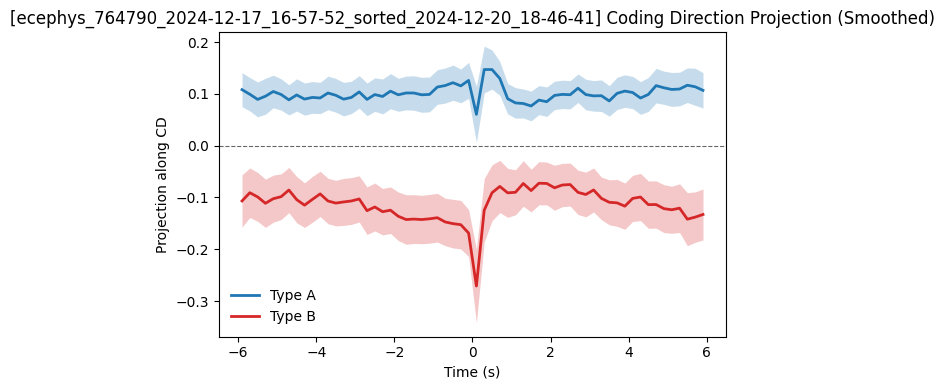

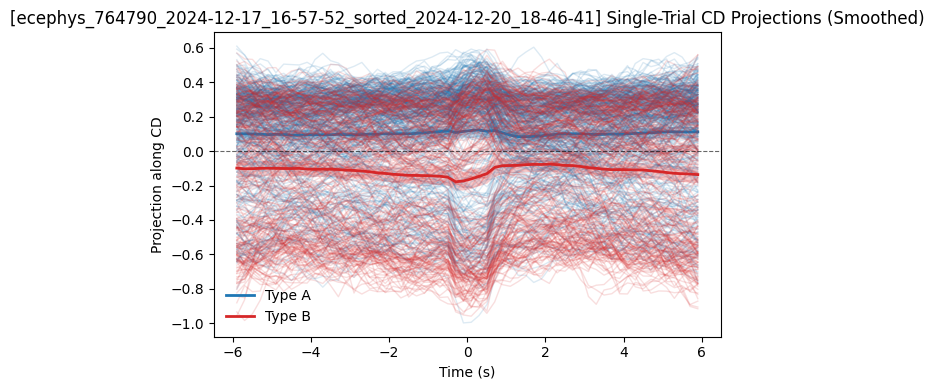

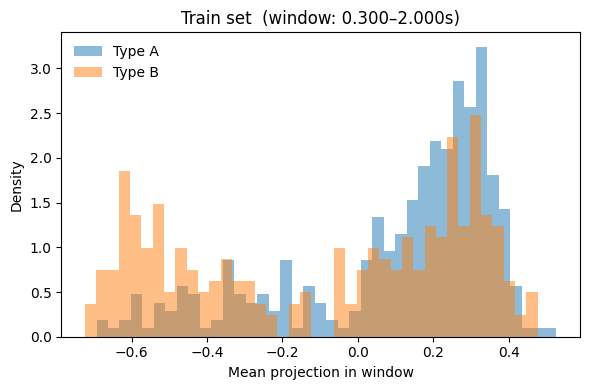

[skip] does not match required suffix: CD_ecephys_764790_2024-12-17_16-57-52_sorted_2024-12-20_18-46-41_RG_MD_right_choice_trials_left_choice_trials_TW_0.3_2.zarr
[skip] does not match required suffix: CD_ecephys_764790_2024-12-18_12-14-41_sorted_2024-12-21_23-37-20_RG_ALL_right_choice_trials_left_choice_trials_TW_-1_0.zarr
[skip] does not match required suffix: CD_ecephys_764790_2024-12-18_12-14-41_sorted_2024-12-21_23-37-20_RG_ALL_right_choice_trials_left_choice_trials_TW_0.3_2.zarr

=== Session: ecephys_764790_2024-12-18_12-14-41_sorted_2024-12-21_23-37-20 ===
File: CD_ecephys_764790_2024-12-18_12-14-41_sorted_2024-12-21_23-37-20_RG_MD_right_choice_trials_left_choice_trials_TW_-1_0.zarr
Train A  (LR / RL): 24 / 0
Train B  (LR / RL): 0 / 24
Test  A  (LR / RL): 24 / 0
Test  B  (LR / RL): 0 / 24


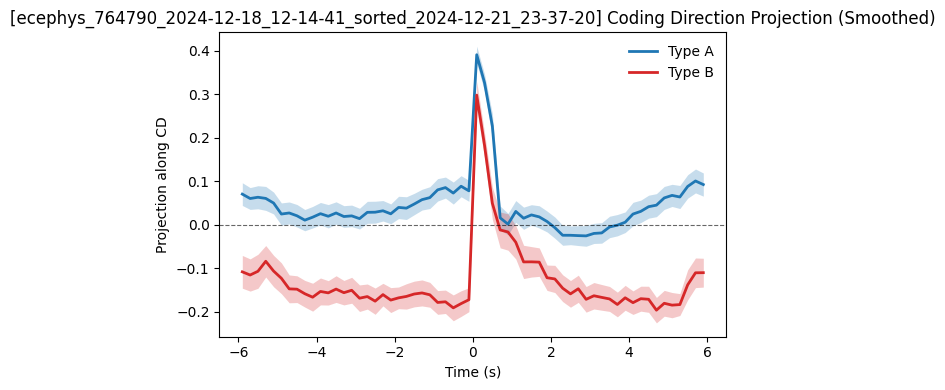

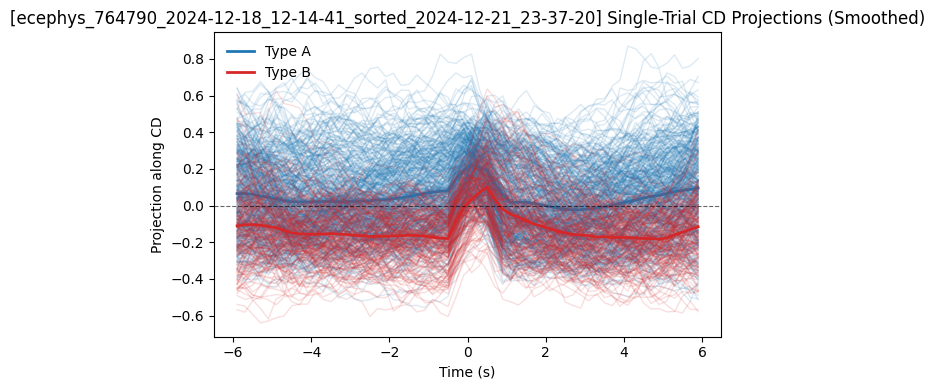

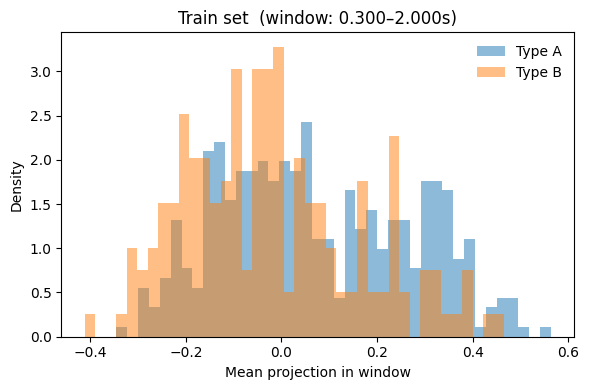

[skip] does not match required suffix: CD_ecephys_764790_2024-12-18_12-14-41_sorted_2024-12-21_23-37-20_RG_MD_right_choice_trials_left_choice_trials_TW_0.3_2.zarr
[skip] does not match required suffix: CD_ecephys_764790_2024-12-19_16-11-34_sorted_2025-02-21_14-46-33_RG_ALL_right_choice_trials_left_choice_trials_TW_-1_0.zarr
[skip] does not match required suffix: CD_ecephys_764790_2024-12-19_16-11-34_sorted_2025-02-21_14-46-33_RG_ALL_right_choice_trials_left_choice_trials_TW_0.3_2.zarr
[skip] does not match required suffix: CD_ecephys_764790_2024-12-19_16-11-34_sorted_2025-02-21_14-46-33_RG_SI_MA_right_choice_trials_left_choice_trials_TW_-1_0.zarr
[skip] does not match required suffix: CD_ecephys_764790_2024-12-19_16-11-34_sorted_2025-02-21_14-46-33_RG_SI_MA_right_choice_trials_left_choice_trials_TW_0.3_2.zarr
[skip] does not match required suffix: CD_ecephys_764790_2024-12-20_16-56-37_sorted_2024-12-22_00-06-37_RG_ALL_right_choice_trials_left_choice_trials_TW_-1_0.zarr
[skip] does not 

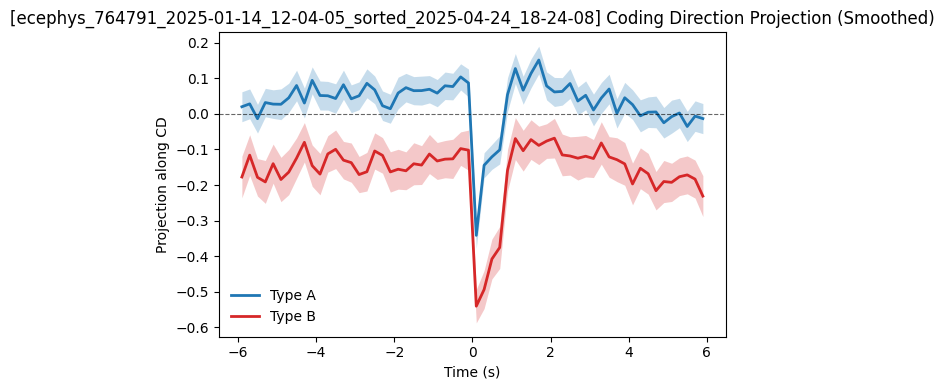

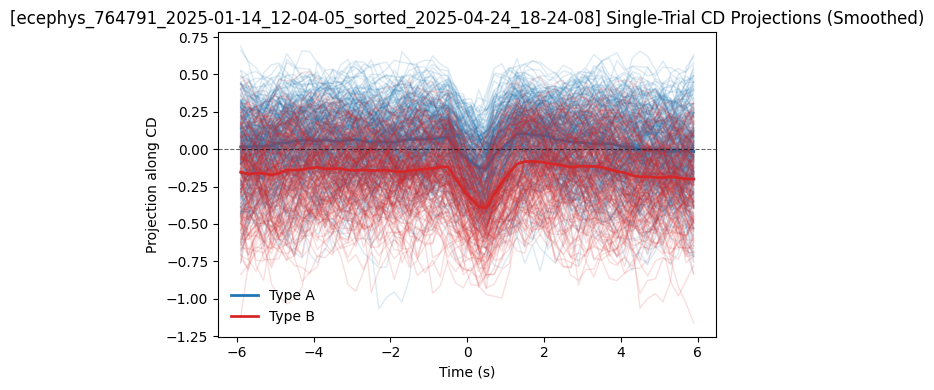

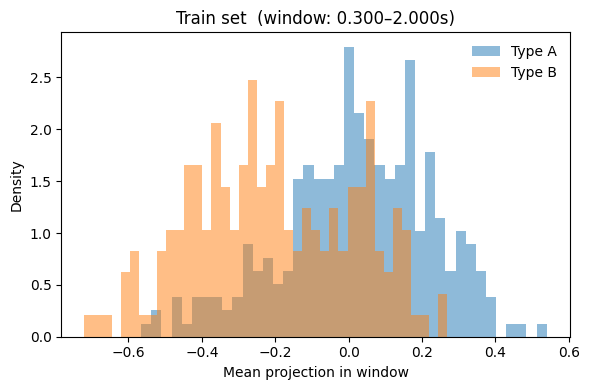

[skip] does not match required suffix: CD_ecephys_764791_2025-01-14_12-04-05_sorted_2025-04-24_18-24-08_RG_MD_right_choice_trials_left_choice_trials_TW_0.3_2.zarr
[skip] does not match required suffix: CD_ecephys_764791_2025-01-16_12-50-17_sorted_2025-04-25_14-11-37_RG_ALL_right_choice_trials_left_choice_trials_TW_-1_0.zarr
[skip] does not match required suffix: CD_ecephys_764791_2025-01-16_12-50-17_sorted_2025-04-25_14-11-37_RG_ALL_right_choice_trials_left_choice_trials_TW_0.3_2.zarr
[skip] does not match required suffix: CD_ecephys_769884_2025-01-14_14-53-24_sorted_2025-01-24_14-20-13_RG_ALL_right_choice_trials_left_choice_trials_TW_-1_0.zarr
[skip] does not match required suffix: CD_ecephys_769884_2025-01-14_14-53-24_sorted_2025-01-24_14-20-13_RG_ALL_right_choice_trials_left_choice_trials_TW_0.3_2.zarr

=== Session: ecephys_769884_2025-01-14_14-53-24_sorted_2025-01-24_14-20-13 ===
File: CD_ecephys_769884_2025-01-14_14-53-24_sorted_2025-01-24_14-20-13_RG_MD_right_choice_trials_left_c

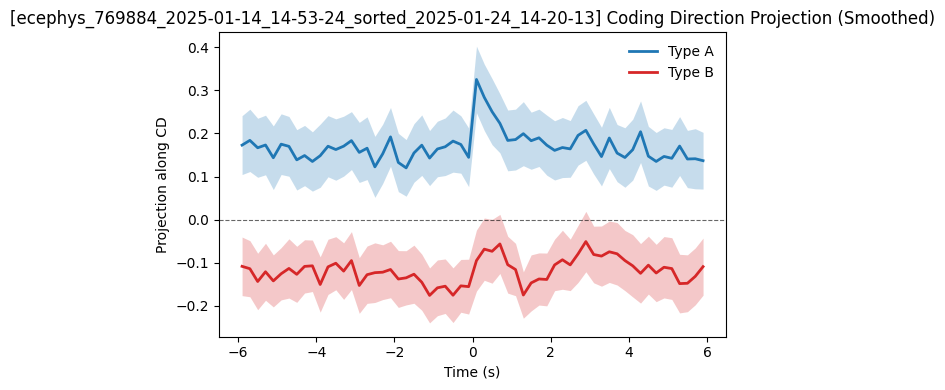

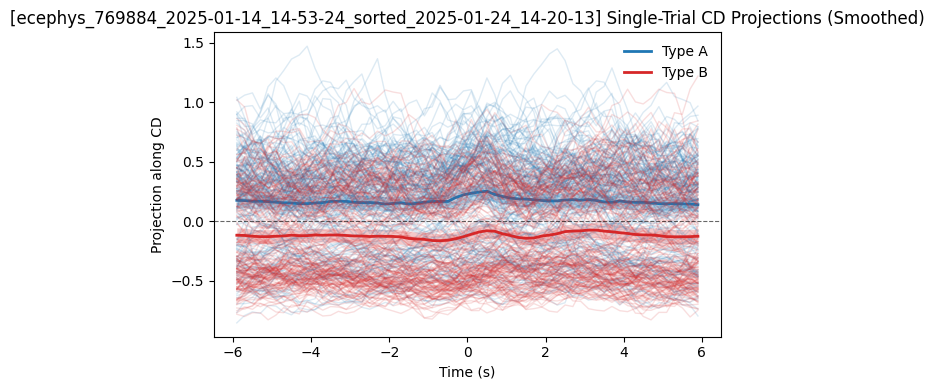

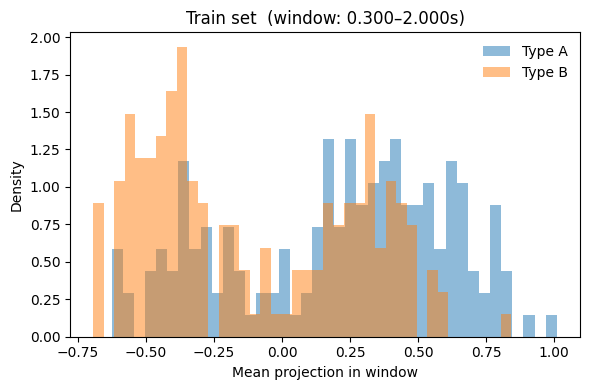

[skip] does not match required suffix: CD_ecephys_769884_2025-01-14_14-53-24_sorted_2025-01-24_14-20-13_RG_MD_right_choice_trials_left_choice_trials_TW_0.3_2.zarr
[skip] does not match required suffix: CD_ecephys_769884_2025-01-15_16-12-59_sorted_2025-04-24_17-11-57_RG_ALL_right_choice_trials_left_choice_trials_TW_-1_0.zarr
[skip] does not match required suffix: CD_ecephys_769884_2025-01-15_16-12-59_sorted_2025-04-24_17-11-57_RG_ALL_right_choice_trials_left_choice_trials_TW_0.3_2.zarr

=== Session: ecephys_769884_2025-01-15_16-12-59_sorted_2025-04-24_17-11-57 ===
File: CD_ecephys_769884_2025-01-15_16-12-59_sorted_2025-04-24_17-11-57_RG_MD_right_choice_trials_left_choice_trials_TW_-1_0.zarr
Train A  (LR / RL): 11 / 0
Train B  (LR / RL): 0 / 11
Test  A  (LR / RL): 11 / 0
Test  B  (LR / RL): 0 / 11


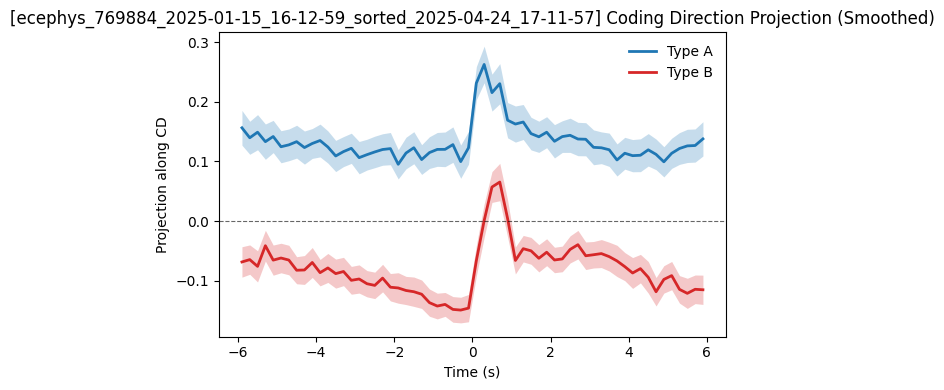

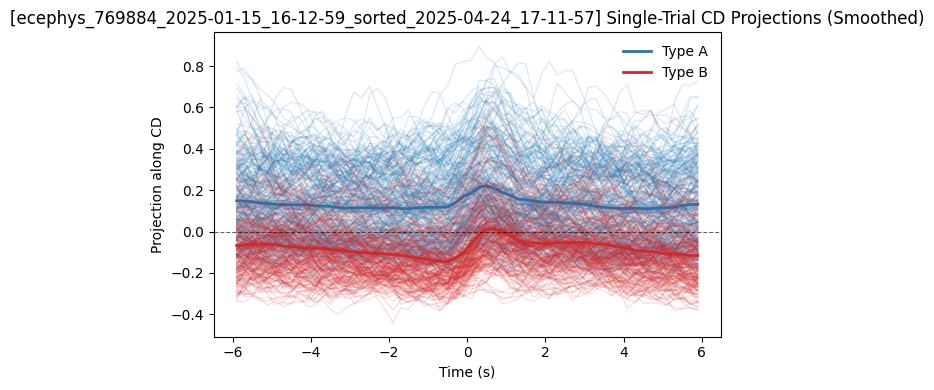

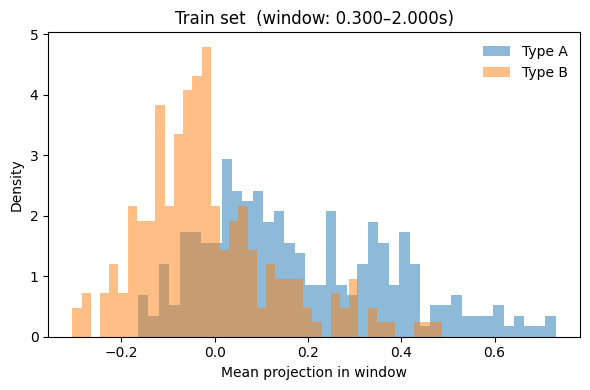

[skip] does not match required suffix: CD_ecephys_769884_2025-01-15_16-12-59_sorted_2025-04-24_17-11-57_RG_MD_right_choice_trials_left_choice_trials_TW_0.3_2.zarr
[skip] does not match required suffix: CD_ecephys_769884_2025-01-16_18-33-11_sorted_2025-04-24_19-24-23_RG_ALL_right_choice_trials_left_choice_trials_TW_-1_0.zarr
[skip] does not match required suffix: CD_ecephys_769884_2025-01-16_18-33-11_sorted_2025-04-24_19-24-23_RG_ALL_right_choice_trials_left_choice_trials_TW_0.3_2.zarr
[skip] does not match required suffix: CD_ecephys_769884_2025-01-16_18-33-11_sorted_2025-04-24_19-24-23_RG_MOs2_3_MOs5_MOs6a_right_choice_trials_left_choice_trials_TW_-1_0.zarr
[skip] does not match required suffix: CD_ecephys_769884_2025-01-16_18-33-11_sorted_2025-04-24_19-24-23_RG_MOs2_3_MOs5_MOs6a_right_choice_trials_left_choice_trials_TW_0.3_2.zarr
[skip] does not match required suffix: CD_ecephys_776293_2025-02-14_15-19-17_sorted_2025-02-28_21-37-07_RG_ALL_right_choice_trials_left_choice_trials_TW_-1

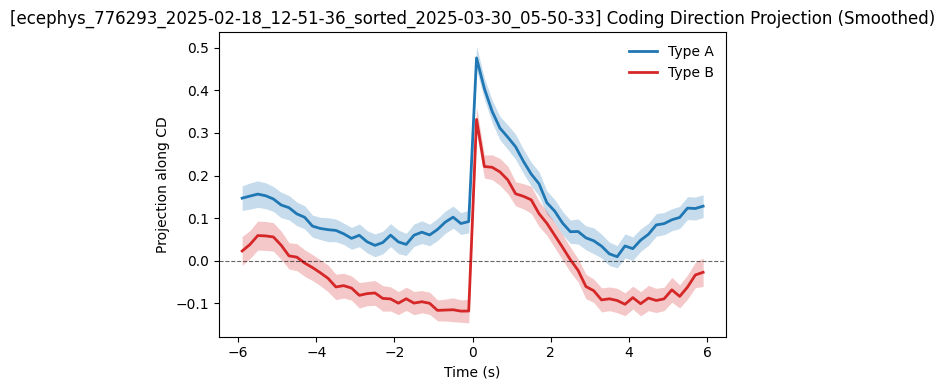

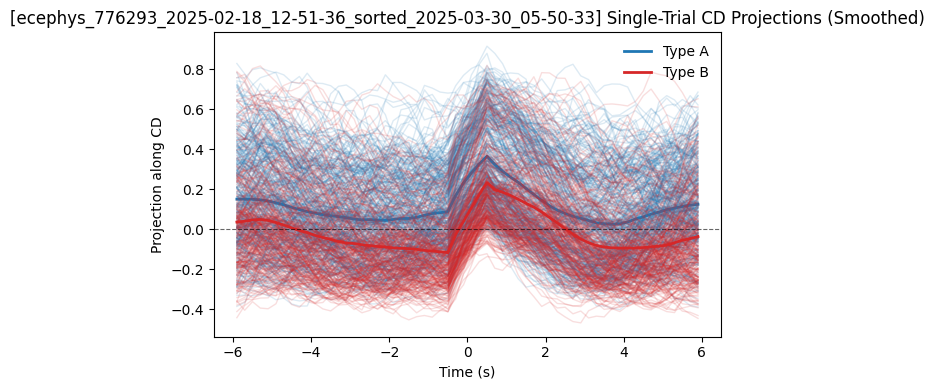

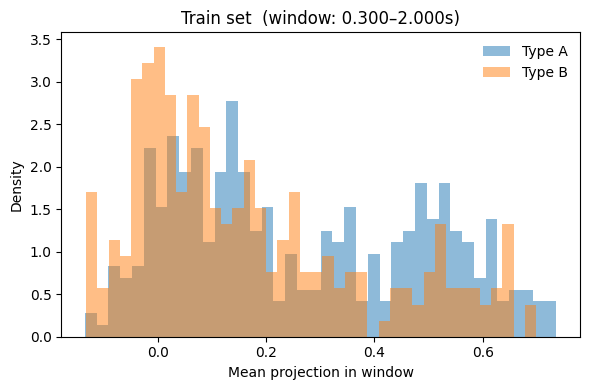

[skip] does not match required suffix: CD_ecephys_776293_2025-02-18_12-51-36_sorted_2025-03-30_05-50-33_RG_MD_right_choice_trials_left_choice_trials_TW_0.3_2.zarr
[skip] does not match required suffix: CD_ecephys_776293_2025-02-18_12-51-36_sorted_2025-03-30_05-50-33_RG_SI_MA_right_choice_trials_left_choice_trials_TW_-1_0.zarr
[skip] does not match required suffix: CD_ecephys_776293_2025-02-18_12-51-36_sorted_2025-03-30_05-50-33_RG_SI_MA_right_choice_trials_left_choice_trials_TW_0.3_2.zarr
[skip] does not match required suffix: CD_ecephys_776293_2025-02-19_14-01-07_sorted_2025-03-30_08-55-28_RG_ALL_right_choice_trials_left_choice_trials_TW_-1_0.zarr
[skip] does not match required suffix: CD_ecephys_776293_2025-02-19_14-01-07_sorted_2025-03-30_08-55-28_RG_ALL_right_choice_trials_left_choice_trials_TW_0.3_2.zarr

=== Session: ecephys_776293_2025-02-19_14-01-07_sorted_2025-03-30_08-55-28 ===
File: CD_ecephys_776293_2025-02-19_14-01-07_sorted_2025-03-30_08-55-28_RG_MD_right_choice_trials_le

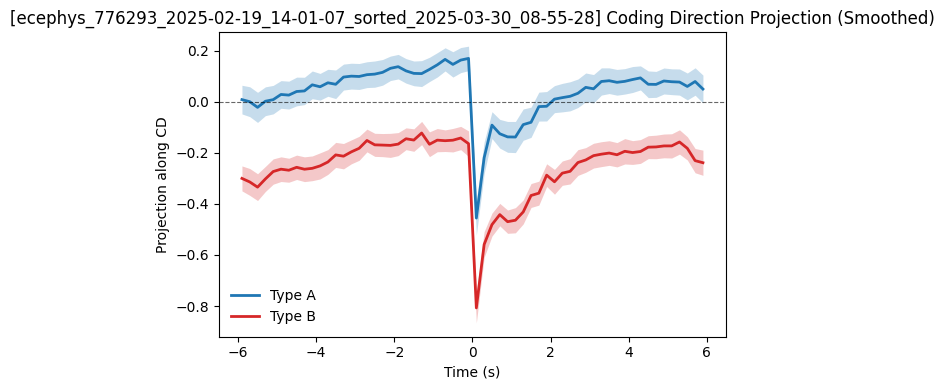

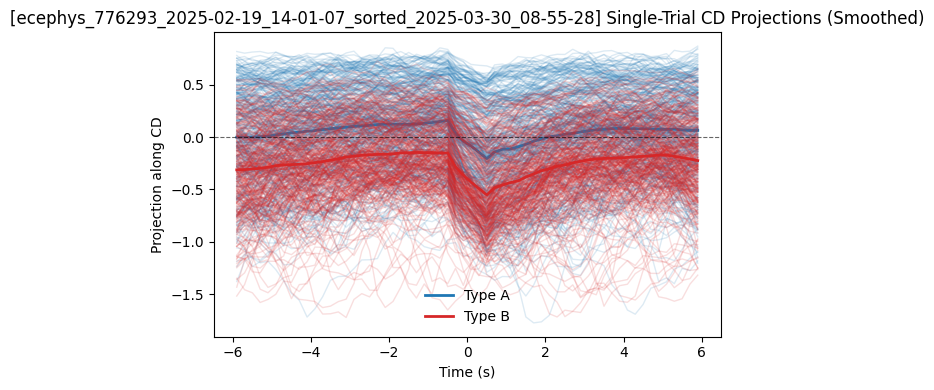

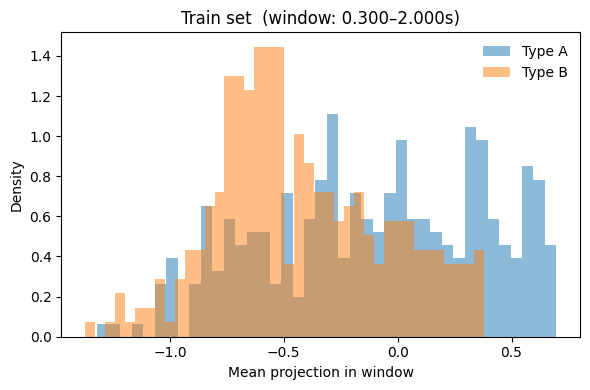

[skip] does not match required suffix: CD_ecephys_776293_2025-02-19_14-01-07_sorted_2025-03-30_08-55-28_RG_MD_right_choice_trials_left_choice_trials_TW_0.3_2.zarr
[skip] does not match required suffix: CD_ecephys_776293_2025-02-19_14-01-07_sorted_2025-03-30_08-55-28_RG_MOs2_3_MOs5_MOs6a_right_choice_trials_left_choice_trials_TW_-1_0.zarr
[skip] does not match required suffix: CD_ecephys_776293_2025-02-19_14-01-07_sorted_2025-03-30_08-55-28_RG_MOs2_3_MOs5_MOs6a_right_choice_trials_left_choice_trials_TW_0.3_2.zarr
[skip] does not match required suffix: CD_ecephys_780618_2025-04-15_13-30-58_sorted_2025-04-18_12-52-04_RG_ALL_right_choice_trials_left_choice_trials_TW_-1_0.zarr
[skip] does not match required suffix: CD_ecephys_780618_2025-04-15_13-30-58_sorted_2025-04-18_12-52-04_RG_ALL_right_choice_trials_left_choice_trials_TW_0.3_2.zarr
[skip] does not match required suffix: CD_ecephys_780618_2025-04-15_13-30-58_sorted_2025-04-18_12-52-04_RG_SI_MA_right_choice_trials_left_choice_trials_TW_

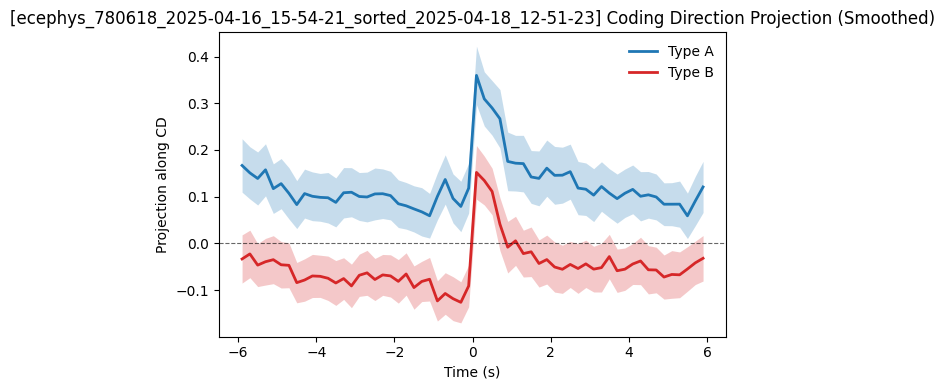

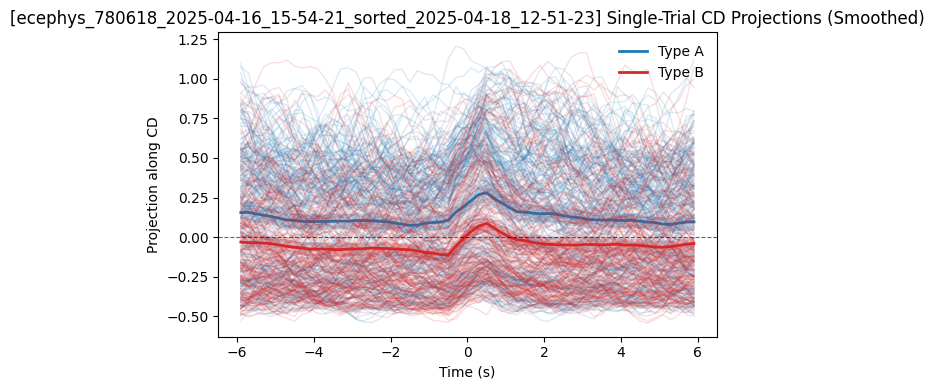

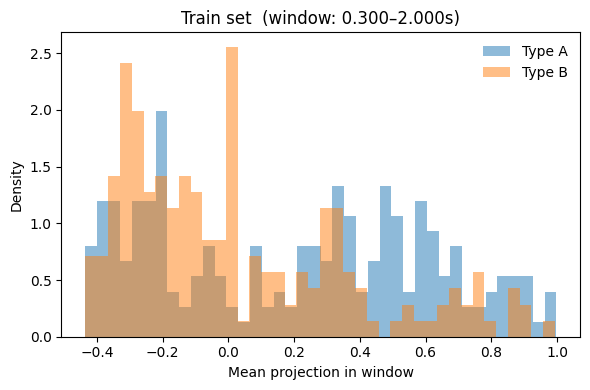

[skip] does not match required suffix: CD_ecephys_780618_2025-04-16_15-54-21_sorted_2025-04-18_12-51-23_RG_MD_right_choice_trials_left_choice_trials_TW_0.3_2.zarr
[skip] does not match required suffix: CD_ecephys_780618_2025-04-16_15-54-21_sorted_2025-04-18_12-51-23_RG_SI_MA_right_choice_trials_left_choice_trials_TW_-1_0.zarr
[skip] does not match required suffix: CD_ecephys_780618_2025-04-16_15-54-21_sorted_2025-04-18_12-51-23_RG_SI_MA_right_choice_trials_left_choice_trials_TW_0.3_2.zarr
[skip] does not match required suffix: CD_ecephys_780618_2025-04-17_13-48-57_sorted_2025-11-07_16-27-28_RG_ALL_right_choice_trials_left_choice_trials_TW_-1_0.zarr
[skip] does not match required suffix: CD_ecephys_780618_2025-04-17_13-48-57_sorted_2025-11-07_16-27-28_RG_ALL_right_choice_trials_left_choice_trials_TW_0.3_2.zarr
[skip] does not match required suffix: CD_ecephys_781469_2025-03-27_18-45-35_sorted_2025-03-30_16-18-11_RG_ALL_right_choice_trials_left_choice_trials_TW_-1_0.zarr
[skip] does not 

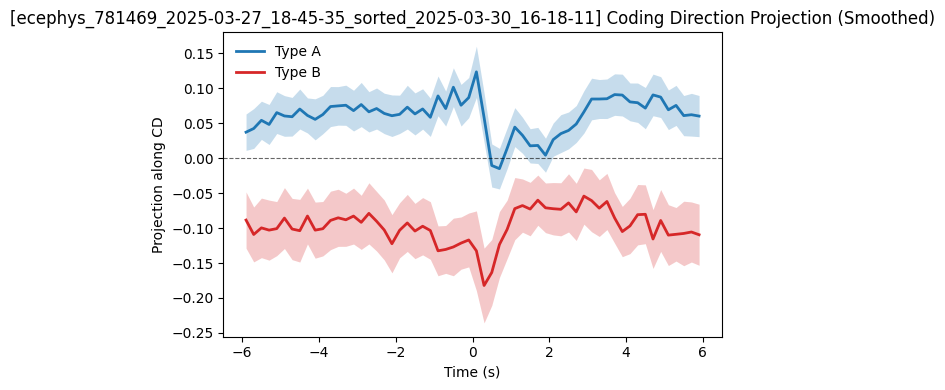

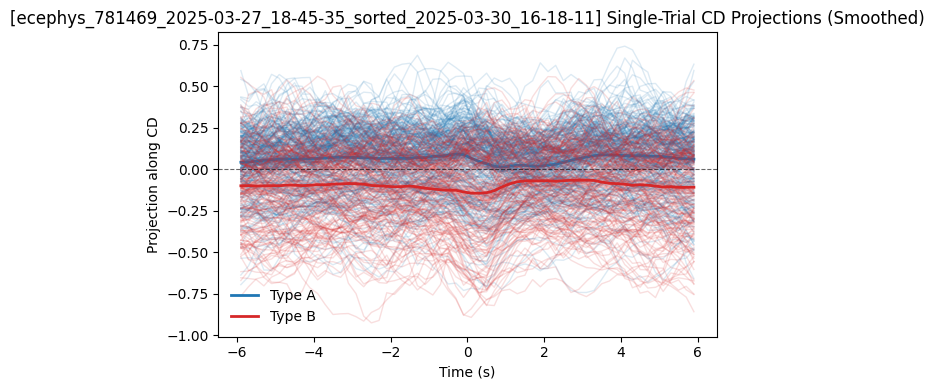

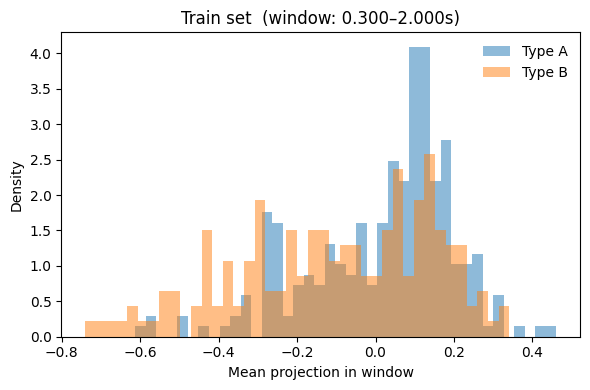

[skip] does not match required suffix: CD_ecephys_781469_2025-03-27_18-45-35_sorted_2025-03-30_16-18-11_RG_MD_right_choice_trials_left_choice_trials_TW_0.3_2.zarr
[skip] does not match required suffix: CD_ecephys_781469_2025-03-29_10-46-53_sorted_2025-03-30_05-48-42_RG_ALL_right_choice_trials_left_choice_trials_TW_-1_0.zarr
[skip] does not match required suffix: CD_ecephys_781469_2025-03-29_10-46-53_sorted_2025-03-30_05-48-42_RG_ALL_right_choice_trials_left_choice_trials_TW_0.3_2.zarr
[skip] does not match required suffix: CD_ecephys_781471_2025-03-27_13-39-06_sorted_2025-03-31_11-52-53_RG_ALL_right_choice_trials_left_choice_trials_TW_-1_0.zarr
[skip] does not match required suffix: CD_ecephys_781471_2025-03-27_13-39-06_sorted_2025-03-31_11-52-53_RG_ALL_right_choice_trials_left_choice_trials_TW_0.3_2.zarr

=== Session: ecephys_781471_2025-03-27_13-39-06_sorted_2025-03-31_11-52-53 ===
File: CD_ecephys_781471_2025-03-27_13-39-06_sorted_2025-03-31_11-52-53_RG_MD_right_choice_trials_left_c

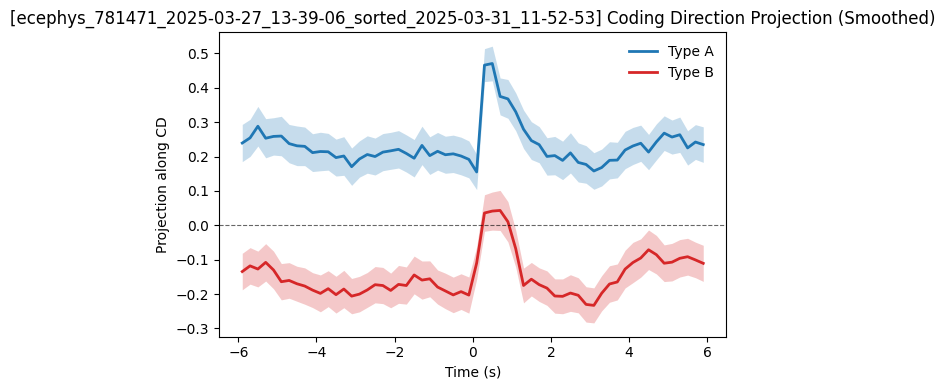

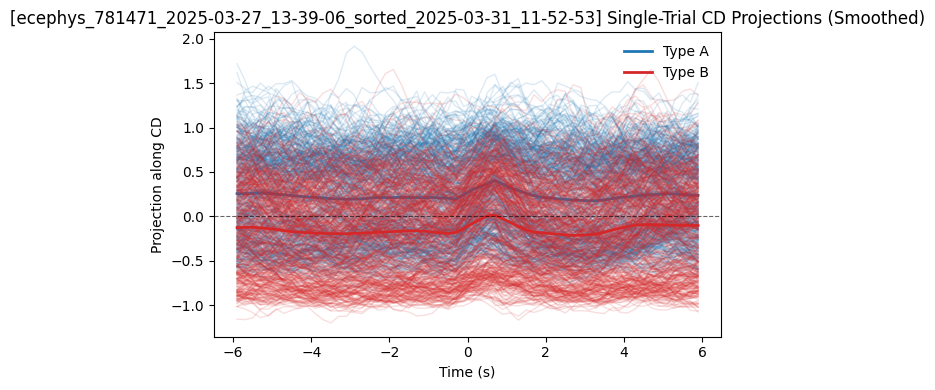

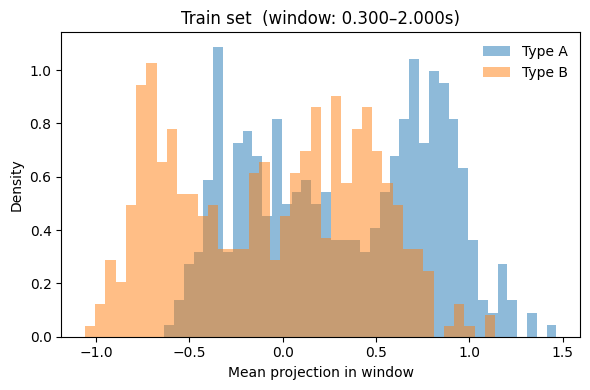

[skip] does not match required suffix: CD_ecephys_781471_2025-03-27_13-39-06_sorted_2025-03-31_11-52-53_RG_MD_right_choice_trials_left_choice_trials_TW_0.3_2.zarr
[skip] does not match required suffix: CD_ecephys_781471_2025-03-28_15-06-14_sorted_2025-03-31_14-10-16_RG_ALL_right_choice_trials_left_choice_trials_TW_-1_0.zarr
[skip] does not match required suffix: CD_ecephys_781471_2025-03-28_15-06-14_sorted_2025-03-31_14-10-16_RG_ALL_right_choice_trials_left_choice_trials_TW_0.3_2.zarr

=== Session: ecephys_781471_2025-03-28_15-06-14_sorted_2025-03-31_14-10-16 ===
File: CD_ecephys_781471_2025-03-28_15-06-14_sorted_2025-03-31_14-10-16_RG_MD_right_choice_trials_left_choice_trials_TW_-1_0.zarr
Train A  (LR / RL): 15 / 0
Train B  (LR / RL): 0 / 15
Test  A  (LR / RL): 15 / 0
Test  B  (LR / RL): 0 / 15


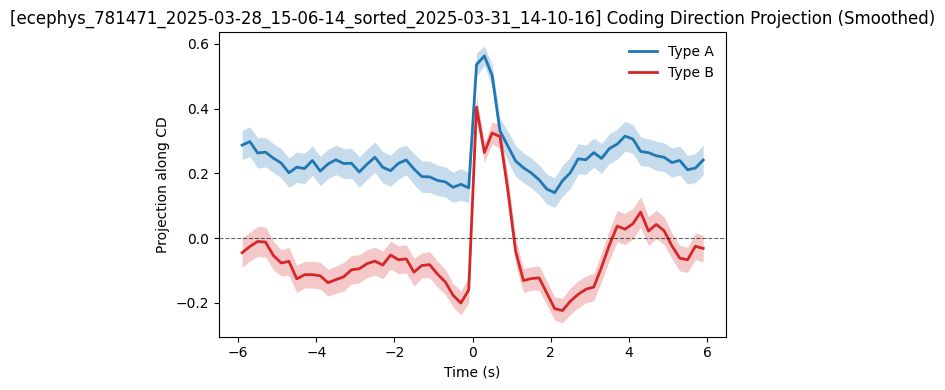

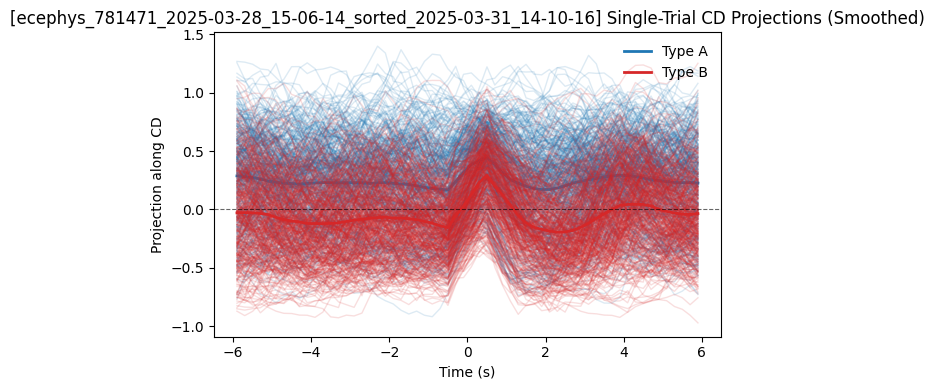

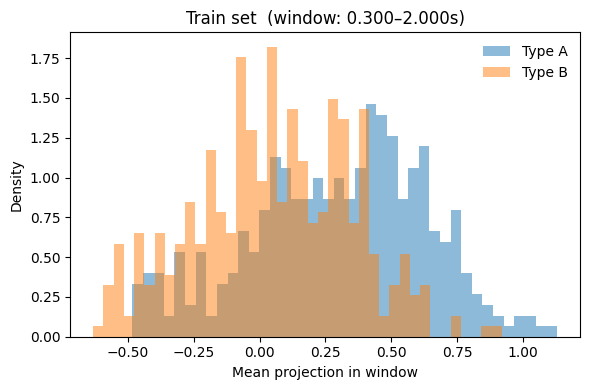

[skip] does not match required suffix: CD_ecephys_781471_2025-03-28_15-06-14_sorted_2025-03-31_14-10-16_RG_MD_right_choice_trials_left_choice_trials_TW_0.3_2.zarr
[skip] does not match required suffix: CD_ecephys_781471_2025-03-31_14-33-03_sorted_2025-04-01_15-50-16_RG_ALL_right_choice_trials_left_choice_trials_TW_-1_0.zarr
[skip] does not match required suffix: CD_ecephys_781471_2025-03-31_14-33-03_sorted_2025-04-01_15-50-16_RG_ALL_right_choice_trials_left_choice_trials_TW_0.3_2.zarr
[skip] does not match required suffix: CD_ecephys_795393_2025-09-11_20-05-17_sorted_2025-10-29_15-06-02_RG_ALL_right_choice_trials_left_choice_trials_TW_-1_0.zarr
[skip] does not match required suffix: CD_ecephys_795393_2025-09-11_20-05-17_sorted_2025-10-29_15-06-02_RG_ALL_right_choice_trials_left_choice_trials_TW_0.3_2.zarr
[skip] does not match required suffix: CD_ecephys_795393_2025-09-15_13-05-25_sorted_2025-10-29_20-10-36_RG_ALL_right_choice_trials_left_choice_trials_TW_-1_0.zarr
[skip] does not matc

In [ ]:
# Per-session CD plots (filtered by region + time-window suffix)
import os

from ephys_dimension_reduction_CD_pipeline import (
    iter_cd_files, load_cd_session, plot_cd_session,
)

cd_root = "/root/capsule/scratch/CD_results/"
behavior_root = "/root/capsule/scratch/behavior_summary"
required_suffix = "_RG_MD_right_choice_trials_left_choice_trials_TW_-1_0"
distribution_window = (0.3, 2)

summary = []
for zpath, session in iter_cd_files(cd_root, required_suffix=required_suffix):
    beh_csv = os.path.join(behavior_root, f"behavior_summary-{session}.csv")
    if not os.path.exists(beh_csv):
        print(f"[skip] behavior CSV not found for {session}")
        continue

    print(f"\n=== Session: {session} ===\nFile: {os.path.basename(zpath)}")
    sess = load_cd_session(zpath, beh_csv)
    counts = sess.counts()
    print(
        "Train A (LR/RL):", counts["train_A_LR"], "/", counts["train_A_RL"],
        "| Train B (LR/RL):", counts["train_B_LR"], "/", counts["train_B_RL"],
        "| Test A (LR/RL):", counts["test_A_LR"], "/", counts["test_A_RL"],
        "| Test B (LR/RL):", counts["test_B_LR"], "/", counts["test_B_RL"],
    )
    summary.append({"session": session, **counts})

    try:
        plot_cd_session(sess, distribution_window=distribution_window)
    except NameError:
        print("plotting helpers not found; skipping plots.")

if summary:
    import pandas as pd
    summary_df = pd.DataFrame(summary)
    out_csv = os.path.join(cd_root, "CD_sessions_switch_counts_summary.csv")
    summary_df.to_csv(out_csv, index=False)
    print("\nSaved summary:", out_csv)
else:
    print("No sessions processed.")



=== Session: ecephys_764769_2024-12-11_18-21-49_sorted_2024-12-13_10-04-48 ===
Zarr: /root/capsule/scratch/CD_results/CD_ecephys_764769_2024-12-11_18-21-49_sorted_2024-12-13_10-04-48_RG_MD_right_choice_trials_left_choice_trials_TW_-1_0.zarr
CSV : /root/capsule/scratch/behavior_summary/behavior_summary-ecephys_764769_2024-12-11_18-21-49_sorted_2024-12-13_10-04-48.csv
Train A  (LR / RL): 12 / 0
Train B  (LR / RL): 0 / 11
Test  A  (LR / RL): 12 / 0
Test  B  (LR / RL): 0 / 11

=== Session: ecephys_764769_2024-12-12_16-05-00_sorted_2024-12-13_10-34-23 ===
Zarr: /root/capsule/scratch/CD_results/CD_ecephys_764769_2024-12-12_16-05-00_sorted_2024-12-13_10-34-23_RG_MD_right_choice_trials_left_choice_trials_TW_-1_0.zarr
CSV : /root/capsule/scratch/behavior_summary/behavior_summary-ecephys_764769_2024-12-12_16-05-00_sorted_2024-12-13_10-34-23.csv
Train A  (LR / RL): 17 / 0
Train B  (LR / RL): 0 / 15
Test  A  (LR / RL): 17 / 0
Test  B  (LR / RL): 0 / 15

=== Session: ecephys_764790_2024-12-17_16-5

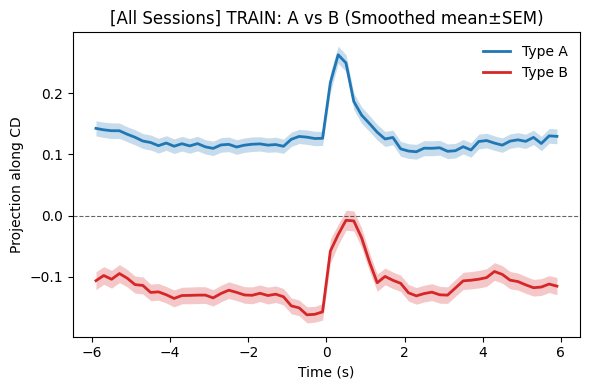

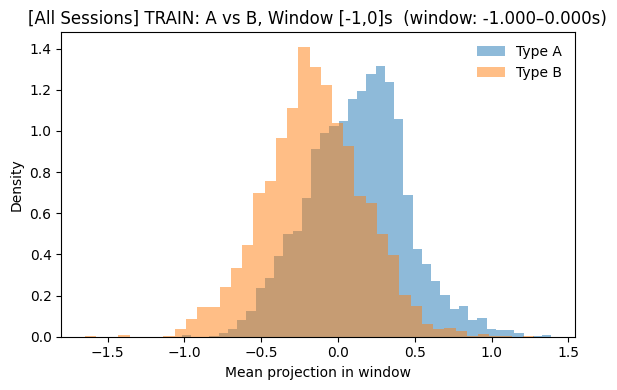

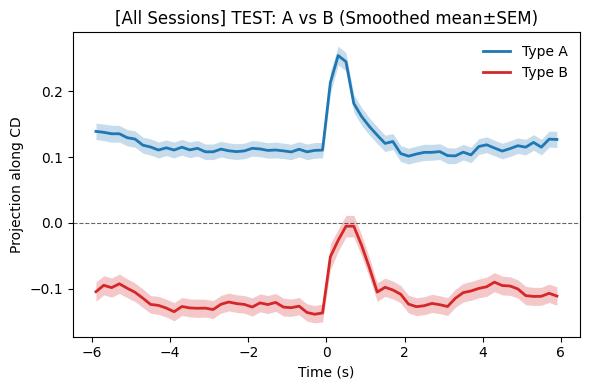

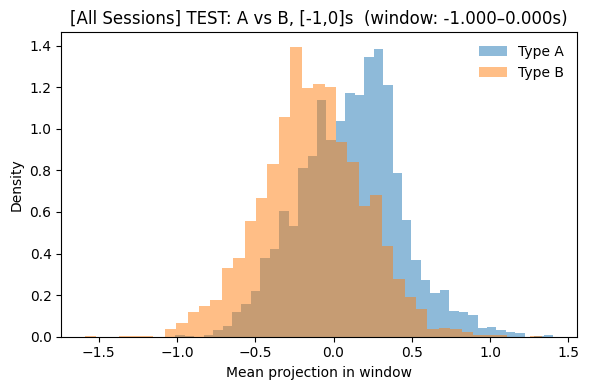

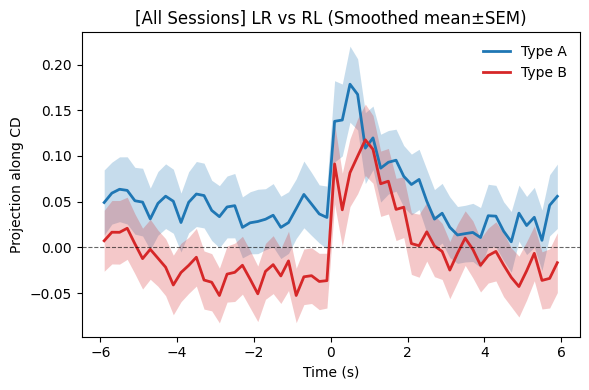

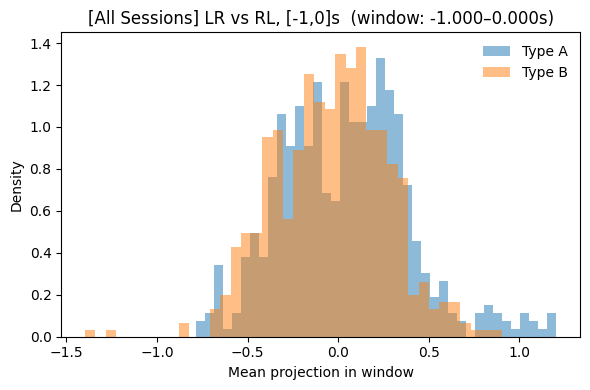

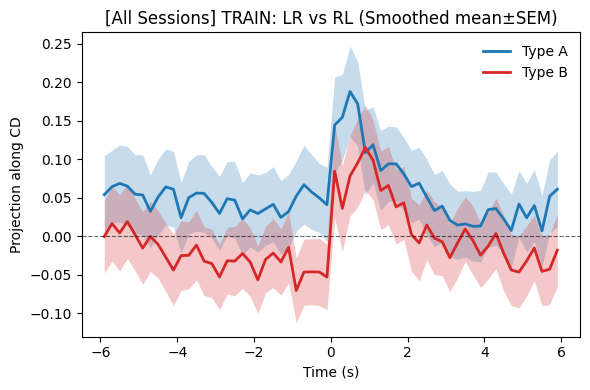

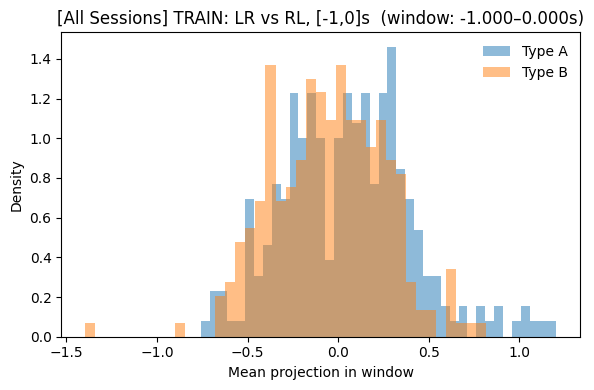

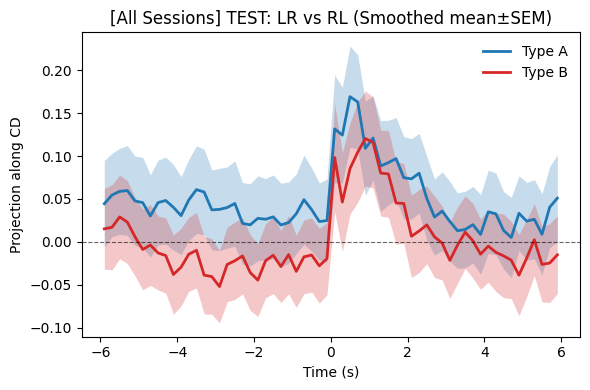

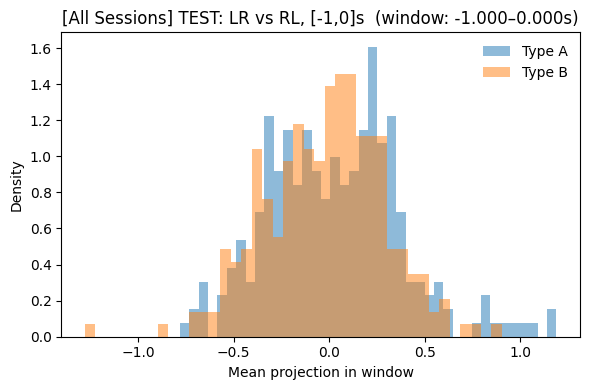

In [ ]:
# Aggregate CD across sessions and plot pooled A-vs-B and LR-vs-RL
import os

from ephys_dimension_reduction_CD_pipeline import (
    iter_cd_files, load_cd_session, aggregate_cd_sessions, plot_cd_aggregate,
)

cd_root = "/root/capsule/scratch/CD_results"
behavior_root = "/root/capsule/scratch/behavior_summary"
target_suffix = "_RG_MD_right_choice_trials_left_choice_trials_TW_-1_0"
distribution_window = (-1, 0)

sessions_data = []
for zpath, session in iter_cd_files(cd_root, required_suffix=target_suffix):
    beh_csv = os.path.join(behavior_root, f"behavior_summary-{session}.csv")
    if not os.path.exists(beh_csv):
        print(f"[skip] behavior CSV not found for {session}")
        continue
    print(f"\n=== Session: {session} ===")
    sessions_data.append(load_cd_session(zpath, beh_csv))

agg = aggregate_cd_sessions(sessions_data)
if not agg.counts_df.empty:
    print("\nSummary across sessions:")
    print(agg.counts_df)
    out_csv = os.path.join("/root/capsule/scratch", "CD_sessions_switch_counts_summary.csv")
    agg.counts_df.to_csv(out_csv, index=False)
    print(f"Saved summary: {out_csv}")

plot_cd_aggregate(agg, distribution_window=distribution_window)



=== Session: ecephys_764769_2024-12-11_18-21-49_sorted_2024-12-13_10-04-48 ===
Zarr: /root/capsule/scratch/CD_results/CD_ecephys_764769_2024-12-11_18-21-49_sorted_2024-12-13_10-04-48_RG_MD_right_choice_trials_left_choice_trials_TW_-1_0.zarr
CSV : /root/capsule/scratch/behavior_summary/behavior_summary-ecephys_764769_2024-12-11_18-21-49_sorted_2024-12-13_10-04-48.csv

=== Session: ecephys_764769_2024-12-12_16-05-00_sorted_2024-12-13_10-34-23 ===
Zarr: /root/capsule/scratch/CD_results/CD_ecephys_764769_2024-12-12_16-05-00_sorted_2024-12-13_10-34-23_RG_MD_right_choice_trials_left_choice_trials_TW_-1_0.zarr
CSV : /root/capsule/scratch/behavior_summary/behavior_summary-ecephys_764769_2024-12-12_16-05-00_sorted_2024-12-13_10-34-23.csv

=== Session: ecephys_764790_2024-12-17_16-57-52_sorted_2024-12-20_18-46-41 ===
Zarr: /root/capsule/scratch/CD_results/CD_ecephys_764790_2024-12-17_16-57-52_sorted_2024-12-20_18-46-41_RG_MD_right_choice_trials_left_choice_trials_TW_-1_0.zarr
CSV : /root/capsul

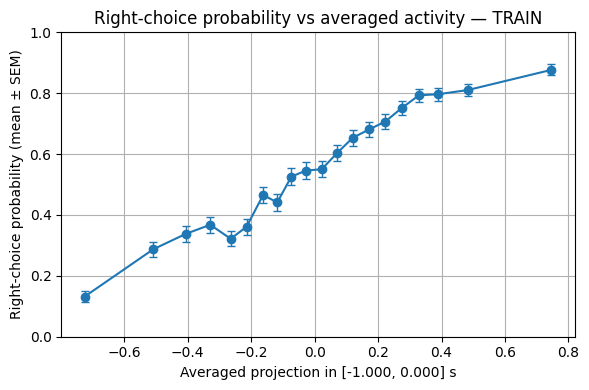

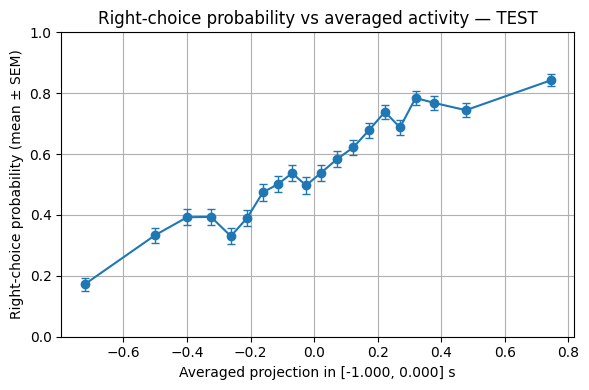

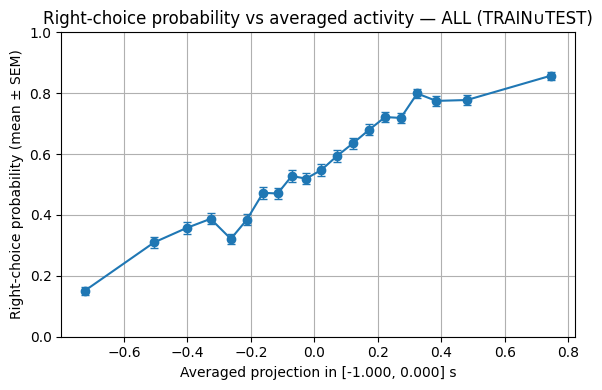

In [ ]:
# Right-choice probability vs averaged CD projection (binned)
import os

from ephys_dimension_reduction_CD_pipeline import (
    iter_cd_files, load_cd_session,
    compute_choice_prob_vs_activity, plot_choice_prob_vs_activity,
)

cd_root = "/root/capsule/scratch/CD_results"
behavior_root = "/root/capsule/scratch/behavior_summary"
target_suffix = "_RG_MD_right_choice_trials_left_choice_trials_TW_-1_0"
activity_avg_window = (-1, 0)
binning_method = "quantile"  # "quantile" or "uniform"
n_bins = 20
error_mode = "SEM"           # "SD" or "SEM"

sessions_data, beh_csvs = [], []
for zpath, session in iter_cd_files(cd_root, required_suffix=target_suffix):
    beh_csv = os.path.join(behavior_root, f"behavior_summary-{session}.csv")
    if not os.path.exists(beh_csv):
        print(f"[skip] behavior CSV not found for {session}")
        continue
    print(f"\n=== Session: {session} ===")
    sessions_data.append(load_cd_session(zpath, beh_csv))
    beh_csvs.append(beh_csv)

data = compute_choice_prob_vs_activity(
    sessions_data, beh_csvs,
    activity_avg_window=activity_avg_window,
    n_bins=n_bins,
    binning_method=binning_method,
    error_mode=error_mode,
)
plot_choice_prob_vs_activity(
    data,
    activity_avg_window=activity_avg_window,
    n_bins=n_bins,
    binning_method=binning_method,
    error_mode=error_mode,
)
